In [25]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, silhouette_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

## 로지스틱 회귀분석
* 종속변수가 범주형일 때 사용하는 통계 분석 기법
결과값을 0~1 사이 확률로 제한

* 어떤 일이 발생할 확률을 예측하고자 할 때 사용
환자가 질병에 걸릴 확률
고객이 이탈할 확률
이메일이 스팸일 확률

* 성능 평가 지표
정확도(Accuracy): 전체 중 맞춘 비율
정밀도(Precision): Positive로 예측한 것 중 실제로 맞은 비율
재현율(Recall): 실제 Positive 중 예측이 맞은 비율
F1-score: 정밀도와 재현율의 조화 평균
AUC: 따른 성능 평가

In [2]:
from sklearn.linear_model import LogisticRegression

In [3]:
# 예제 데이터 생성
data = {
    'study_hours': [1, 2, 3, 4, 5, 6, 6.5, 7, 8, 9, 2, 3, 4, 5, 1.5, 8.5, 7.5, 4.5],
    'sleep_hours': [8, 7.5, 7, 6.5, 6, 5.5, 6, 5.5, 5, 4.5, 8, 7, 6, 5.5, 8.5, 4, 4.5, 6],
    'pass_exam':    [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
df

,study_hours,sleep_hours,pass_exam
0,1.0,8.0,0
1,2.0,7.5,0
2,3.0,7.0,0
3,4.0,6.5,0
4,5.0,6.0,1
5,6.0,5.5,1
6,6.5,6.0,1
7,7.0,5.5,1
8,8.0,5.0,1
9,9.0,4.5,1


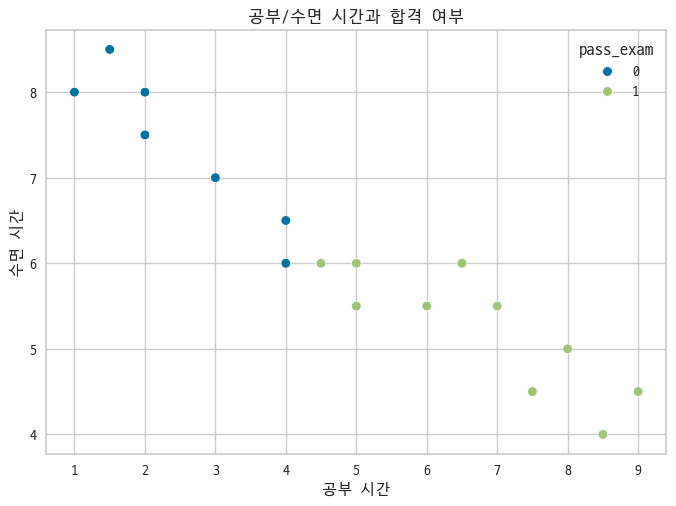

In [4]:
sns.scatterplot(x='study_hours', y='sleep_hours', hue='pass_exam', data=df)
plt.title("공부/수면 시간과 합격 여부")
plt.xlabel("공부 시간")
plt.ylabel("수면 시간")
plt.grid(True)
plt.show()

In [6]:
# 독립변수와 종속변수
X = df[['study_hours', 'sleep_hours']]
y = df['pass_exam']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 생성, 학습
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
from sklearn.metrics import classification_report

## 절편, 회귀 계수 확인
print(f"절편 (intercept): {model.intercept_}")
print(f"기울기 (coef): {model.coef_}")

## 예측 및 평가
y_pred = model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

절편 (intercept): [-1.73896588]
기울기 (coef): [[ 1.24005733 -0.58718463]]
Confusion Matrix:
 [[2 0]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [8]:
## 새로운 데이터로 예측

# 공부 5시간, 수면 6시간이면?
print(model.predict([[5, 6]]))

# 확률로 보기
print(model.predict_proba([[5, 6]]))

[1]
[[0.28126145 0.71873855]]


In [9]:
new_data = [
    [5, 6],   # 공부5, 수면6
    [2, 8],   # 공부2, 수면8
    [7, 5],   # 공부7, 수면5
    [3, 7]
]

print(model.predict(new_data))
print(model.predict_proba(new_data))

[1 0 1 0]
[[0.28126145 0.71873855]
 [0.98122597 0.01877403]
 [0.01788911 0.98211089]
 [0.89369824 0.10630176]]


# 유방암 데이터셋

In [11]:
b_cancer = load_breast_cancer()
b_cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [12]:
b_cancer_df = pd.DataFrame(b_cancer.data, columns = b_cancer.feature_names)
b_cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
b_cancer_df['diagnosis']= b_cancer.target
b_cancer_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [15]:
b_cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [16]:
scaler = StandardScaler()
b_cancer_scaled = scaler.fit_transform(b_cancer.data)

In [17]:
# 독립변수와 종속변수
Y = b_cancer_df['diagnosis']
X = b_cancer_scaled

In [18]:
# 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0)

In [19]:
# 로지스틱 회귀모델 생성 및 학습
lr_b_cancer = LogisticRegression()
lr_b_cancer.fit(X_train, Y_train)

# 예측
Y_predict = lr_b_cancer.predict(X_test)

In [27]:
# 모델의 성능 확인
acccuracy = accuracy_score(Y_test, Y_predict)
precision = precision_score(Y_test, Y_predict)
recall = recall_score(Y_test, Y_predict)
f1 = f1_score(Y_test, Y_predict)
roc_auc = roc_auc_score(Y_test, Y_predict)

print( '정확도: {0:.3f}, 정밀도: {1:.3f}, 재현율: {2:.3f}, F1: {3:.3f}'.format(acccuracy,precision,recall,f1))

print('ROC_AUC: {0:.3f}'.format(roc_auc))

정확도: 0.977, 정밀도: 0.973, 재현율: 0.991, F1: 0.982
ROC_AUC: 0.972


#### ROC_AUC = “이 모델이 0과 1을 얼마나 잘 구분하는가”의 점수 
#### => accuracy보다 더 신뢰도 높은 평가 지표로 사용

#### ROC-AUC 값의 범위
0 ~ 1 사이 숫자

| 값      | 의미             |
| ------ | -------------- |
| 1.0    | 완벽             |
| 0.9 이상 | 매우 좋음          |
| 0.8    | 괜찮음            |
| 0.7    | 보통             |
| 0.5    | 랜덤과 동일 (쓸모 없음) |
| 0.5 미만 | 완전 반대로 예측      |

In [ ]:
## 새로운 데이터로 예측

# 1. 새로운 데이터 (특성 30개)
new_data = [[
14.5, 20.3, 95.1, 700.2, 0.1, 0.2, 0.15, 0.07, 0.18, 0.06,
0.5, 1.2, 3.2, 40.0, 0.005, 0.02, 0.03, 0.01, 0.02, 0.003,
16.0, 25.0, 110.0, 800.0, 0.14, 0.25, 0.30, 0.12, 0.28, 0.09
]]

# 2. 표준화 (fit 하지말고, transform만!)
new_scaled = scaler.transform(new_data)

# 3. 예측
pred = lr_b_cancer.predict(new_scaled)

# 4. 결과 출력
print("예측 숫자:", pred)
print("예측 이름:", b_cancer.target_names[pred])

proba = lr_b_cancer.predict_proba(new_scaled)
print("확률:", proba)

예측 숫자: [0]
예측 이름: ['malignant']
확률: [[0.87729052 0.12270948]]
